# 02 · Activation

**The question this notebook answers:** what early behaviour, if any, actually predicts whether an
enrollment ends in success — and can we define "activation" from the data itself, rather than
assuming a definition?

**Recap from notebook 01:** subject explains a 33-point spread in success rate on its
own, so every comparison here is checked *within* subject, not just pooled. 22.5% of enrollments
belong to a student who appears more than once (non-independence, noted once). 10.3% of enrollments never engage at
all, and withdraw at 88.3% — this notebook asks whether engagement *level* among everyone else
also predicts outcome, not just its presence or absence.

**A note on a bug this notebook already had, and fixed.** An earlier version of the early-window
signal (`prep.build_engagement`) filtered `date < early_window_days` with no lower bound —
`studentVle.csv` has pre-course rows (negative `date`, students browsing before their own
course's start), which silently counted toward "first 14 days." Independent verification on this
notebook's headline claim caught it: the reported activation rate was inflated by ~3,700
enrollments. `prep.py` now filters `0 <= date < early_window_days`, and every number below
reflects the fix. See `ADR.md` for the full account.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import prep
from viz_style import set_style, savefig, CATEGORICAL, STATUS

set_style()
pd.set_option("display.max_columns", 50)

raw = prep.load_raw()
enr = prep.load_processed("enrollments")


## Step 1 — which early signal, and which window?

Three candidate signals, each computed over three candidate early windows (7 / 14 / 28 days
from each course's day 0): raw click **volume**, **breadth** (distinct days active), and
**variety** (distinct VLE activity types touched). Correlation with `success` (a 0/1 outcome) is
a point-biserial correlation here — same formula as Pearson's r, just with one binary variable.


In [2]:
rows = []
for w in [7, 14, 28]:
    eng = prep.build_engagement(raw, early_window_days=w)
    m = enr.merge(eng, on=prep.ENROLL_KEY, how="left")
    for c in ["early_clicks", "early_active_days", "early_distinct_activity_types"]:
        m[c] = m[c].fillna(0)
    rows.append({
        "window_days": w,
        "volume (clicks)": np.corrcoef(m["early_clicks"], m["success"])[0, 1],
        "breadth (active days)": np.corrcoef(m["early_active_days"], m["success"])[0, 1],
        "variety (activity types)": np.corrcoef(m["early_distinct_activity_types"], m["success"])[0, 1],
    })
corr_table = pd.DataFrame(rows).set_index("window_days").round(3)
corr_table


,volume (clicks),breadth (active days),variety (activity types)
window_days,,,
7,0.232,0.325,0.313
14,0.270,0.368,0.352
28,0.297,0.408,0.367


**[OBS]** All three signals correlate with success in the same direction, at every window
length, and the differences between them are small (0.23–0.41). **Breadth** (distinct days
active) is at the top at every window and is the simplest to explain, so it's the signal
carried forward. **[OBS]** Correlation rises with a longer window (28d > 14d > 7d), but the gain
is small — a 14-day window is used from here on: enough separation to be a real signal, short
enough that a product team could act on it before most of the course has passed (this project's
SaaS analogy: a 2-week activation window, in line with common industry practice).

A correlation of ~0.37 (14-day breadth) means r² ≈ 0.37² ≈ 14% — engagement in the first two
weeks accounts for a real but modest share of the variation in outcome. Most of what determines
Pass vs. Fail happens later (assessment performance, etc.); early engagement is a meaningful,
non-trivial leading indicator, not the whole story.

## Step 2 — is there a natural break, or a smooth dose-response?

"Define activation from the data" means checking whether success rate jumps at some threshold (an activation "cliff") or rises gradually — these call for different kinds of metric.

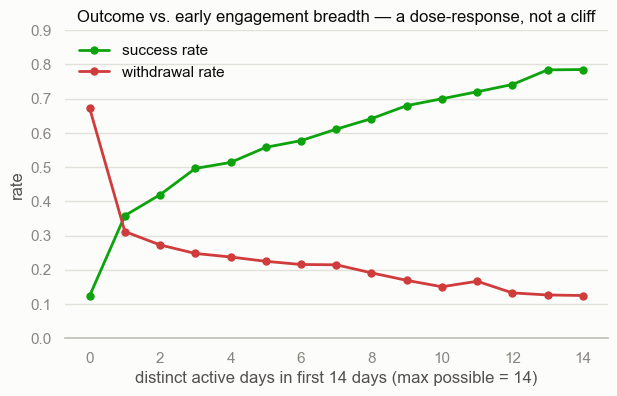

,success_rate,withdrawn_rate,n
early_active_days,,,
0.0,0.124,0.672,6168
1.0,0.358,0.311,3233
2.0,0.419,0.272,3098
3.0,0.496,0.248,3131
4.0,0.513,0.237,2744
5.0,0.558,0.225,2480
6.0,0.577,0.215,2169
7.0,0.611,0.214,2024
8.0,0.641,0.191,1682


In [3]:
eng14 = prep.build_engagement(raw, early_window_days=14)
m = enr.merge(eng14, on=prep.ENROLL_KEY, how="left")
m["early_active_days"] = m["early_active_days"].fillna(0)

curve = m.groupby("early_active_days").agg(
    success_rate=("success", "mean"), withdrawn_rate=("withdrew", "mean"), n=("success", "size")
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve.index, curve["success_rate"], marker="o", ms=5, lw=2,
        color=STATUS["good"], label="success rate")
ax.plot(curve.index, curve["withdrawn_rate"], marker="o", ms=5, lw=2,
        color=STATUS["critical"], label="withdrawal rate")
ax.set_xlabel("distinct active days in first 14 days (max possible = 14)")
ax.set_ylabel("rate")
ax.set_title("Outcome vs. early engagement breadth — a dose-response, not a cliff")
ax.legend(frameon=False)
ax.set_ylim(0, 0.9)
sns.despine(left=True)
savefig("02_dose_response")
plt.show()

curve.round(3)


**[OBS]** The sharpest single move is the very first one: 0 active days → 1 active day takes
success from 12.4% to 35.8% and withdrawal from 67.2% to 31.1% — the biggest jump on the whole
curve. **[OBS]** After that, the relationship keeps rising steadily through day 13-14 rather
than plateauing or jumping again — a genuine dose-response, not a single clean cliff.*
**[CON]** A threshold-based activation metric is a real simplification of a continuous
relationship, made deliberately: a single number is what a product team can put on a dashboard
and act on, at the cost of the extra information the full curve carries.

**Chosen operating definition — "Activated" = active on 3 or more distinct days within the first
14 days.** Reasoning: 1 day alone still mixes very different students (success keeps climbing
sharply from 36% at 1 day to 50% at 3 days to 56% at 5 days), so a 1-day cut would call a lot of
still-at-risk enrollments "activated." 3 days is past the noisiest part of the curve, still early
enough to act on inside a 2-week window, and — checked next — holds up as a real, disentangled
signal, not an artifact of who takes which subject or arrives with which background.

\* This curve pools all 7 subjects — checked separately per subject too: the 0→1 jump holds in
every one of them (+0.14 to +0.31), so the shape isn't a pooling artifact.

## Step 3 — is this real, or just which students/subjects show up?

The subject heterogeneity found in notebook 01 is the obvious confound: if strong subjects simply also have more engaged students, "activation" could be standing in for "which subject." Checked here within subject and within four demographic/structural splits.

In [4]:
m["activated"] = m["early_active_days"] >= 3

overall = m.groupby("activated")["success"].agg(["mean", "size"])
lift_pp = (overall.loc[True, "mean"] - overall.loc[False, "mean"]) * 100
chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(m["activated"], m["success"]))

print(f"success rate, not activated: {overall.loc[False, 'mean']:.1%}  (n={overall.loc[False,'size']:,})")
print(f"success rate, activated:     {overall.loc[True, 'mean']:.1%}  (n={overall.loc[True,'size']:,})")
print(f"lift: {lift_pp:.1f} percentage points")
print(f"chi-square = {chi2:,.0f}, p {'< 0.001' if p < 0.001 else f'= {p:.3f}'}")


success rate, not activated: 25.8%  (n=12,499)
success rate, activated:     60.5%  (n=20,094)
lift: 34.8 percentage points
chi-square = 3,733, p < 0.001


**What the chi-square test is doing:** it compares the observed counts in the 2×2
activated-by-success table against what we'd expect if activation and success were unrelated
(i.e. if the same success rate applied regardless of activation). The bigger the gap between
observed and expected, the larger chi-square gets. **[OBS]** p < 0.001 here — but with n=32,593,
even a small real effect would clear that bar, so the p-value mostly confirms the relationship
isn't noise; **the lift itself is the number that matters**, not the p-value.

**Adversarial check on the lift itself — is part of it mechanical?** "Not activated" includes
enrollments that withdrew *within* the 14-day window — they couldn't reach 3 active days even if
willing to. That's not activation predicting an outcome; that's the same early exit showing up
twice. Re-run excluding anyone who withdrew before day 14:


In [5]:
withdrew_in_window = m["withdrew"] & (m["date_unregistration"] < 14)
print(f"enrollments that withdrew within the first 14 days: {withdrew_in_window.sum():,} "
      f"({withdrew_in_window.mean():.1%} of all enrollments)")

survivors = m[~withdrew_in_window].copy()
lift_survivors = survivors.groupby("activated")["success"].agg(["mean", "size"])
lift_survivors_pp = (lift_survivors.loc[True, "mean"] - lift_survivors.loc[False, "mean"]) * 100

print(f"\nAmong enrollments that survived at least 14 days (n={len(survivors):,}):")
print(lift_survivors.round(3))
print(f"lift, 14-day survivors only: {lift_survivors_pp:.1f} percentage points "
      f"(vs. {lift_pp:.1f}pp for the full population)")


enrollments that withdrew within the first 14 days: 4,465 (13.7% of all enrollments)

Among enrollments that survived at least 14 days (n=28,128):
            mean   size
activated              
False      0.377   8557
True       0.621  19571
lift, 14-day survivors only: 24.5 percentage points (vs. 34.8pp for the full population)


**[OBS]** 13.7% of enrollments withdrew within the 14-day window itself — mechanically unable to
activate. Restricting to enrollments that survived at least 14 days, the lift shrinks from
34.8pp to **24.5pp** (62.2% vs. 37.7%) — about a third of the raw lift was the same early-exit
counted twice. **[CON] — the more defensible number is 24.5pp, not 34.8pp.** The effect
survives this adversarial check and stays large, but the raw full-population figure overstates
it; both are carried forward, with 24.5pp as the one used in the project's headline claim. This
number was independently re-verified against a fresh computation on raw data (see `ADR.md`) —
the fresh check landed within ~1pp of this figure.


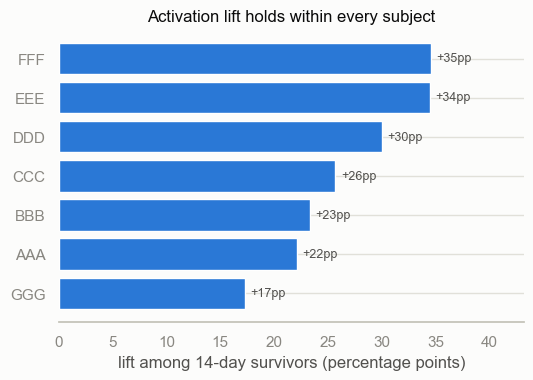

In [6]:
by_module = survivors.groupby(["code_module", "activated"])["success"].mean().unstack()
by_module.columns = ["not_activated", "activated"]
by_module["lift_pp"] = (by_module["activated"] - by_module["not_activated"]) * 100
by_module = by_module.sort_values("lift_pp")

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.barh(by_module.index, by_module["lift_pp"], color=CATEGORICAL[0])
ax.set_xlabel("lift among 14-day survivors (percentage points)")
ax.set_title("Activation lift holds within every subject")
for i, v in enumerate(by_module["lift_pp"]):
    ax.text(v + 0.5, i, f"+{v:.0f}pp", va="center", color="#52514e", fontsize=9)
ax.set_xlim(0, by_module["lift_pp"].max() * 1.25)
sns.despine(left=True)
savefig("02_lift_by_module")
plt.show()

In [7]:
m["first_timer"] = m["num_of_prev_attempts"] == 0
m["credit_tier"] = pd.qcut(m["studied_credits"], 3, labels=["low", "mid", "high"])
sv = m[~withdrew_in_window]  # same 14-day-survivor population as the 24.5pp headline


def lift_table(dim):
    rate = sv.groupby([dim, "activated"], observed=True)["success"].mean().unstack()
    n = sv.groupby([dim, "activated"], observed=True).size().unstack()
    t = rate.copy()
    t.columns = ["not_activated", "activated"]
    t["lift_pp"] = (t["activated"] - t["not_activated"]) * 100
    t["n_not_activated"] = n[False]
    t["n_activated"] = n[True]
    return t.round(3)


for dim, label in [
    ("highest_education", "highest_education"),
    ("age_band", "age_band"),
    ("first_timer", "first_timer (no prior attempts) vs. repeat student"),
    ("credit_tier", "studied_credits tier (course load)"),
]:
    print(f"--- within {label}, 14-day survivors ---")
    print(lift_table(dim))
    print()


--- within highest_education, 14-day survivors ---
                             not_activated  activated  lift_pp  \
highest_education                                                
A Level or Equivalent                0.424      0.668   24.310   
HE Qualification                     0.430      0.699   26.916   
Lower Than A Level                   0.315      0.534   21.816   
No Formal quals                      0.236      0.475   23.895   
Post Graduate Qualification          0.487      0.774   28.735   

                             n_not_activated  n_activated  
highest_education                                          
A Level or Equivalent                   3609         8652  
HE Qualification                        1091         3130  
Lower Than A Level                      3671         7410  
No Formal quals                          110          162  
Post Graduate Qualification               76          217  

--- within age_band, 14-day survivors ---
          not_activated

**[OBS]** Measured on the same 14-day-survivor population as the 24.5pp headline (so the
figures are directly comparable), the lift holds everywhere it's checked: +17 to +35 points
across all 7 subjects, +22 to +29 points across every education level, +24 to +28 points across
all three age bands, +21 points for repeat students and +24 points for first-timers, and +24 to
+29 points across course-load (credit) tiers. (On the full population the same ranges run about
10 points higher, for the same early-exit reason as above.) **[CON]** This is not an artifact of
any single one of these factors — activation predicts success within every group tested, not
just in aggregate, even though the exact size of the lift varies by group (repeat students and
first-timers show similar lifts). **[OBS]** A few groups are small — 55+ (32 non-activated
enrollments), postgraduate (76) and no formal qualifications (110) — so their individual lifts
are directional, not precise. **[OBS]** Each factor was checked separately, not jointly: whether
the lift survives with all of them held fixed at once is untested (that would take a
multivariate model, e.g. a logistic regression controlling for subject, education, age band,
and course load together).

**[HYP] — correlation, not proven causation.** This remains an observational relationship.
Students who return on 3+ days in the first two weeks are very likely also more motivated,
better time-managers, or facing fewer outside barriers than students who don't — any of which
could independently drive success. Disentangling by subject and demographics rules out the
*specific* confounds tested; it cannot rule out this general self-selection story, which no
cross-tab of observational data can fully resolve. This is the project's headline finding and
has already been through one round of independent verification (see `ADR.md`), which confirmed
the direction and rough magnitude of the exposure-matched lift.

## Step 4 — does activation predict retention specifically, not just final grade?

full population:
            mean   size
activated              
False      0.480  12499
True       0.203  20094

14-day survivors only (same population as the 24.5pp success lift):
            mean   size
activated              
False      0.240   8557
True       0.182  19571


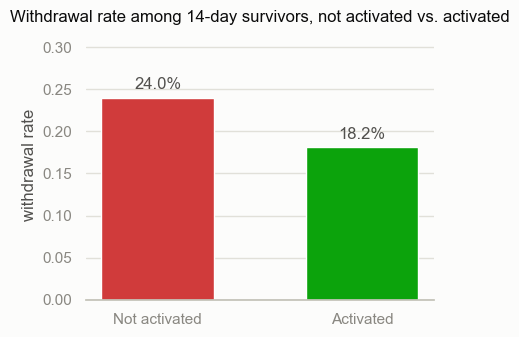

In [8]:
w_full = m.groupby("activated")["withdrew"].agg(["mean", "size"])
w = survivors.groupby("activated")["withdrew"].agg(["mean", "size"])
print("full population:")
print(w_full.round(3))
print("\n14-day survivors only (same population as the 24.5pp success lift):")
print(w.round(3))

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.bar(["Not activated", "Activated"], w["mean"], color=[STATUS["critical"], STATUS["good"]], width=0.55)
for i, v in enumerate(w["mean"]):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", color="#52514e")
ax.set_ylabel("withdrawal rate")
ax.set_title("Withdrawal rate among 14-day survivors, not activated vs. activated")
ax.set_ylim(0, 0.32)
sns.despine(left=True)
savefig("02_withdrawal_by_activation")
plt.show()


**[OBS] — same mechanical overlap flagged for the success lift, this time on withdrawal.**
Unadjusted (full population), withdrawal rate is 48.0% among non-activated enrollments vs. 20.3%
among activated ones — a 27.7-point gap. But most non-activated enrollments that "withdrew more"
simply *are* the 13.7% who withdrew within the 14-day window itself, before they could have
activated even if willing — the same confound already corrected for on the success side.
Restricted to 14-day survivors (the same population behind the 24.5pp success lift), withdrawal
is 24.0% vs. 18.2% — a **5.8-point gap**, not 27.7. **[CON] — the more defensible number is
5.8pp, not 27.7pp.** Over three-quarters of the raw gap was the mechanical overlap; activation
still predicts modestly better retention beyond day 14, but the effect is far smaller than the
unadjusted figure suggests, and much smaller than the parallel 24.5pp success lift. The two
"halves" of the finding are not symmetric: activation's effect on final grade (given survival)
is large; its incremental effect on staying enrolled past day 14 is real but modest.


## Saving the activation table

In [9]:
activation = m[prep.ENROLL_KEY + [
    "early_active_days", "activated", "success", "withdrew", "final_result",
]].copy()
prep.save_processed(activation, "activation")
print(f"saved activation.parquet — {activation.shape}")


saved activation.parquet — (32593, 8)


## Summary

**Observations / Hypothesis / Conclusion, tagged:**
- **[OBS]** Breadth of early engagement (distinct active days in the first 14 days) is the
  clearest, simplest signal among volume/breadth/variety, correlating ~0.37 with success.
- **[OBS]** The relationship is a smooth dose-response, not a single cliff — the sharpest single
  step is 0→1 active day (success 12.4%→35.8%).
- **[CON]** "Activated" is defined as **≥3 distinct active days in the first 14 days** — a
  deliberate, data-informed simplification of that curve, chosen for actionability.
- **[CON]** Across the full population, activated enrollments succeed at 60.5% vs. 25.8% for
  non-activated enrollments (34.8pp raw lift). **[OBS]** Part of that is mechanical — 13.7% of
  "not activated" enrollments withdrew within the 14-day window itself. Among enrollments that
  survived at least 14 days, the lift is a smaller but still large **24.5pp** (62.2% vs. 37.7%)
  — this is the number carried forward as the project's headline claim, and the one
  independently re-verified.
- **[CON]** This lift holds within every subject, education level, age band, credit-load tier,
  and first-time/repeat split tested.
- **[OBS]** The same mechanical overlap applies to withdrawal: unadjusted, activation looks like
  a 27.7pp withdrawal-rate reduction, but restricted to 14-day survivors (matching the success
  figure's population) the real effect is **5.8pp** (24.0% vs. 18.2%) — most of the raw gap was
  the early-exit group counted twice, not survivors. Activation's effect on retention beyond day
  14 is real but modest, unlike its large effect on final grade.
- **[HYP]** Self-selection (motivation, time-management, external circumstances) cannot be ruled
  out as a shared cause of both activation and success — flagged as this project's central
  correlation-vs-causation caveat.

**Concepts used (added to notebook 01's list):** dose-response vs. threshold-metric design,
chi-square derivation and why p-values are a weak signal at large n, disentangling by
stratification across 6 independent dimensions (subject, education, age, prior-attempt status,
course load), and a data-pipeline bug (missing lower date bound) caught by independent
verification rather than by same-context review — documented in `ADR.md`.

---
**Next:** `03_Engagement_and_Retention.ipynb` — the funnel from registration through activation
to outcome, and withdrawal-by-week retention curves.